In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv(
    r"C:\Users\ASUS\OneDrive\Desktop\Ecommerce-Sales-Profitability-Analysis\data\raw\ecommerce_orders_dataset.csv"
)

In [3]:
total_revenue = df["Order_Amount"].sum()
total_profit = df["Profit_Amount"].sum()

average_order_value = df["Order_Amount"].mean()
average_profit_per_record = df["Profit_Amount"].mean()

overall_profit_margin = (
    total_profit / total_revenue * 100
    if total_revenue != 0 else np.nan
)

print("Total Revenue:", round(total_revenue, 2))
print("Total Profit:", round(total_profit, 2))
print("Average Order Amount:", round(average_order_value, 2))
print("Average Profit per Record:", round(average_profit_per_record, 2))
print("Overall Profit Margin (%):", round(overall_profit_margin, 2))

Total Revenue: 11370043.99
Total Profit: 2215916.27
Average Order Amount: 379.0
Average Profit per Record: 73.86
Overall Profit Margin (%): 19.49


## 4.1 Overall Business Performance Analysis

### Objective

To evaluate the overall financial performance of the e-commerce business using key performance indicators (KPIs).

### Key Findings

* **Total Revenue:** 11,370,043.99
* **Total Profit:** 2,215,916.27
* **Average Order Amount per Record:** 379.00
* **Average Profit per Record:** 73.86
* **Overall Profit Margin:** 19.49%

### Business Interpretation

The dataset records total revenue of approximately 11.37 million and total profit of approximately 2.22 million. The calculated overall profit margin is 19.49%, indicating that the recorded profit is approximately 19.49 for every 100 in recorded revenue.

The average order amount per record is 379.00. This measure should be interpreted as an average per order only after confirming that each row represents a unique order.

### Conclusion

The initial performance analysis establishes a baseline for evaluating the business's revenue and profitability. Further analysis will compare products, categories, customer segments, and discount levels to identify opportunities to improve business performance.


In [4]:
category_analysis = (
    df.groupby("Product_Category")
      .agg(
          Total_Revenue=("Order_Amount", "sum"),
          Total_Profit=("Profit_Amount", "sum"),
          Average_Profit=("Profit_Amount", "mean"),
          Record_Count=("Product_Category", "size")
      )
)

category_analysis["Profit_Margin_Percent"] = (
    category_analysis["Total_Profit"]
    / category_analysis["Total_Revenue"] * 100
)

category_analysis = category_analysis.sort_values(
    "Total_Profit", ascending=False
)

display(category_analysis.round(2))

,Total_Revenue,Total_Profit,Average_Profit,Record_Count,Profit_Margin_Percent
Product_Category,,,,,
Electronics,6320059.31,1040688.00,221.47,4699,16.47
Home & Kitchen,1768963.43,379418.20,90.47,4194,21.45
Fashion,1323929.17,344642.74,56.57,6092,26.03
Sports,661447.69,139758.27,57.30,2439,21.13
Beauty,460243.32,134401.18,45.24,2971,29.20
Groceries,360727.15,76057.26,14.14,5380,21.08
Toys,279307.23,60150.95,29.17,2062,21.54
Books,195366.69,40799.67,18.86,2163,20.88


### 4.2 Product Category Profitability Analysis

**Objective**

To compare product categories based on revenue, total profit, average profit, and profit margin, and identify opportunities to improve profitability.

**Key Findings**

* **Electronics** generated the highest revenue (6,320,059.31) and total profit (1,040,688.00), but had the lowest profit margin (16.47%).
* **Beauty** achieved the highest profit margin at 29.20%, despite generating less total profit than Electronics.
* **Fashion** recorded the second-highest profit margin at 26.03%.
* **Groceries** had the highest record count (5,380) and the lowest average profit per record (14.14).
* All eight product categories recorded positive total profit in the analyzed dataset.

**Business Interpretation**

Electronics is the largest contributor to overall profit, but its comparatively low margin suggests an opportunity to investigate product costs, discounts, supplier pricing, and shipping expenses. Beauty and Fashion have higher margins, making them useful categories for further product-level analysis.

Groceries generates a large number of records but a relatively low average profit per record. Further investigation is needed to determine whether this reflects lower selling prices, quantities, costs, or a combination of factors.

**Recommendations**

1. Investigate the cost structure and discount patterns of Electronics products to identify opportunities to improve margins.
2. Examine the products and sales conditions associated with the higher margins in Beauty and Fashion.
3. Analyze Groceries at the product level to understand its relatively low average profit per record.
4. Evaluate both total profit and profit margin before making decisions about product promotion or inventory.

**Conclusion**

The category analysis reveals differences in scale and profitability. Electronics leads in total profit, while Beauty leads in profit margin. These findings provide a foundation for more detailed discount and product-level analysis. All recommendations should be validated using the underlying data before business decisions are made.


In [5]:
# Create discount groups
df["Discount_Group"] = pd.cut(
    df["Discount_Percent"],
    bins=[-0.01, 10, 20, 30, 40],
    labels=["0–10%", "10–20%", "20–30%", "30–40%"]
)

# Check the groups
print(df["Discount_Group"].value_counts(sort=False))

Discount_Group
0–10%     16255
10–20%     7768
20–30%     4184
30–40%     1793
Name: count, dtype: int64


In [6]:
discount_analysis = (
    df.groupby("Discount_Group", observed=False)
      .agg(
          Record_Count=("Order_ID", "size"),
          Total_Revenue=("Order_Amount", "sum"),
          Total_Profit=("Profit_Amount", "sum"),
          Average_Profit=("Profit_Amount", "mean")
      )
)

discount_analysis["Profit_Margin_Percent"] = (
    discount_analysis["Total_Profit"]
    / discount_analysis["Total_Revenue"] * 100
)

display(discount_analysis.round(2))

,Record_Count,Total_Revenue,Total_Profit,Average_Profit,Profit_Margin_Percent
Discount_Group,,,,,
0–10%,16255,6666888.08,1423507.47,87.57,21.35
10–20%,7768,2826260.99,506446.16,65.20,17.92
20–30%,4184,1339573.09,213257.29,50.97,15.92
30–40%,1793,537321.83,72705.35,40.55,13.53


### 4.3 Discount Effectiveness Analysis

**Objective:**
To investigate how different discount levels affect revenue, total profit, average profit, and profit margin.

**Key Findings:**

* **0–10% discount:** Generated the highest total profit of 1,423,507.47 and the highest profit margin of 21.35%.
* **10–20% discount:** Generated a total profit of 506,446.16, with a profit margin of 17.92%.
* **20–30% discount:** Generated a total profit of 213,257.29, with a profit margin of 15.92%.
* **30–40% discount:** Had the lowest total profit of 72,705.35 and the lowest profit margin of 13.53%.
* Average profit per record decreased from 87.57 in the 0–10% discount group to 40.55 in the 30–40% group.

**Business Interpretation:**

The analysis indicates that higher discount groups are associated with lower average profit and profit margins. The 0–10% discount group contributes the highest total profit and has the strongest profit margin among the four groups.

However, these results do not prove that discounts alone cause profits to decrease. Differences in products, sales volumes, and customer purchasing patterns may also influence profitability.

**Business Recommendations:**

1. Review high-discount transactions to understand their effect on profitability.
2. Prefer lower discounts when they can achieve the desired sales results.
3. Evaluate whether higher discounts generate enough additional sales to justify the reduced profit margin.
4. Compare discount levels across product categories before changing pricing strategies.

**Conclusion:**

The 0–10% discount group performs best in terms of total profit and profit margin in this dataset. The business should evaluate discount strategies carefully to maintain profitability while attracting customers.


In [7]:
segment_analysis = (
    df.groupby("Customer_Segment")
      .agg(
          Record_Count=("Order_ID", "size"),
          Total_Revenue=("Order_Amount", "sum"),
          Total_Profit=("Profit_Amount", "sum"),
          Average_Profit=("Profit_Amount", "mean")
      )
)

segment_analysis["Profit_Margin_Percent"] = (
    segment_analysis["Total_Profit"]
    / segment_analysis["Total_Revenue"] * 100
)

segment_analysis = segment_analysis.sort_values(
    "Total_Profit", ascending=False
)

display(segment_analysis.round(2))

,Record_Count,Total_Revenue,Total_Profit,Average_Profit,Profit_Margin_Percent
Customer_Segment,,,,,
Returning,11987,4582714.19,888003.26,74.08,19.38
New,7794,2982575.91,579346.30,74.33,19.42
Loyal,7214,2659608.61,526075.50,72.92,19.78
Premium,3005,1145145.28,222491.21,74.04,19.43


### 4.4 Customer Segment Analysis

**Objective:** To identify the customer segments that contribute the most revenue and profit.

**Key Metrics:**

* Total revenue by customer segment
* Total profit by customer segment
* Average profit per record
* Profit margin percentage

**Business Interpretation:** The segment with the highest total profit is the largest contributor to profitability in this dataset. However, total profit should be considered alongside profit margin and record count to understand whether a segment is profitable because of its size or its efficiency.

**Business Recommendations:**

1. Identify and retain high-value customer segments.
2. Investigate segments with high revenue but comparatively low profit margins.
3. Develop targeted promotions based on segment performance.
4. Evaluate both total profit and profit margin before allocating marketing budgets.

**Conclusion:** Customer segmentation can help the business direct marketing resources toward customer groups that contribute meaningfully to revenue and profitability.


In [8]:
df["Order_Date"] = pd.to_datetime(df["Order_Date"], errors="coerce")

monthly_analysis = (
    df.dropna(subset=["Order_Date"])
      .assign(Month=lambda x: x["Order_Date"].dt.to_period("M").astype(str))
      .groupby("Month")
      .agg(
          Total_Revenue=("Order_Amount", "sum"),
          Total_Profit=("Profit_Amount", "sum"),
          Record_Count=("Order_ID", "size")
      )
      .reset_index()
)

monthly_analysis["Profit_Margin_Percent"] = (
    monthly_analysis["Total_Profit"]
    / monthly_analysis["Total_Revenue"] * 100
)

display(monthly_analysis.round(2))

,Month,Total_Revenue,Total_Profit,Record_Count,Profit_Margin_Percent
0,2023-01,286490.57,55697.86,715,19.44
1,2023-02,253970.94,49578.51,580,19.52
2,2023-03,269086.84,54753.15,648,20.35
3,2023-04,208666.60,43798.44,573,20.99
4,2023-05,237289.67,45893.57,633,19.34
5,2023-06,234097.27,47622.28,620,20.34
6,2023-07,224420.24,43827.34,628,19.53
7,2023-08,272804.15,51646.29,636,18.93
8,2023-09,238898.61,43080.10,632,18.03
9,2023-10,227353.20,45908.90,613,20.19


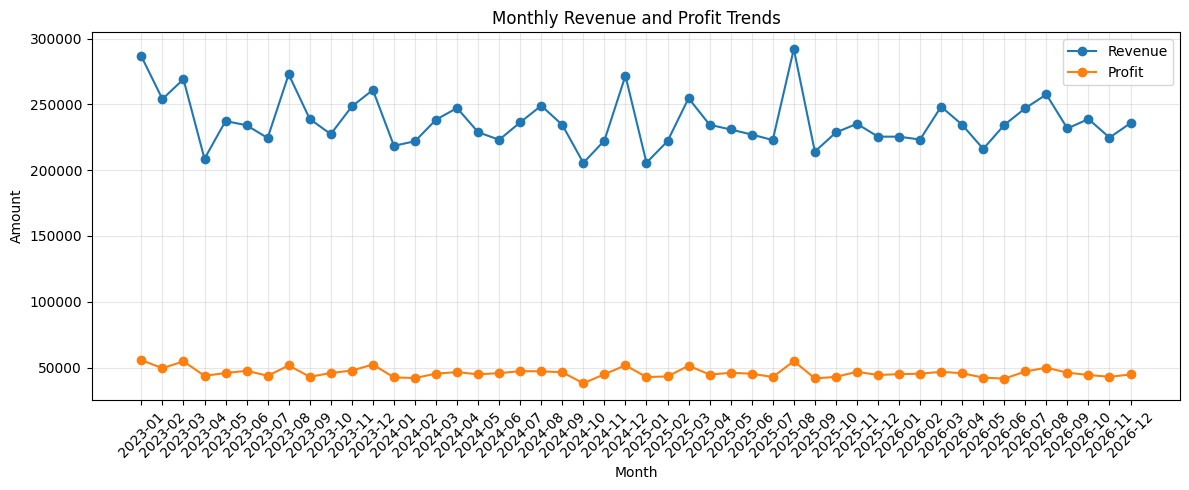

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.plot(
    monthly_analysis["Month"],
    monthly_analysis["Total_Revenue"],
    marker="o",
    label="Revenue"
)
plt.plot(
    monthly_analysis["Month"],
    monthly_analysis["Total_Profit"],
    marker="o",
    label="Profit"
)

plt.title("Monthly Revenue and Profit Trends")
plt.xlabel("Month")
plt.ylabel("Amount")
plt.xticks(rotation=45)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 4.5 Monthly Sales and Profit Trends

**Objective:** To examine how revenue and profit change over time.

**Business Interpretation:** Monthly analysis helps identify periods of strong or weak performance. A month with high revenue may not necessarily have the highest profit, so both metrics should be considered. Any seasonal pattern should be confirmed using the actual monthly results and, ideally, multiple years of data.

**Business Recommendations:**

1. Investigate months with unusually low revenue or profit.
2. Plan inventory and marketing activities around recurring periods of strong demand.
3. Review discounts and operating costs during months when profit margins decline.
4. Compare multiple periods before concluding that a seasonal trend exists.

**Conclusion:** Monthly performance tracking helps the business plan sales activities and monitor changes in profitability over time.


In [10]:
print(df.columns.tolist())

['Order_ID', 'Customer_ID', 'Order_Date', 'Year', 'Month', 'Day', 'Day_Of_Week', 'Quarter', 'Customer_Age', 'Customer_Gender', 'Country', 'City', 'Customer_Segment', 'Product_ID', 'Product_Category', 'Product_Subcategory', 'Brand', 'Unit_Price', 'Quantity', 'Discount_Percent', 'Discount_Amount', 'Coupon_Used', 'Shipping_Cost', 'Tax_Amount', 'Order_Amount', 'Payment_Method', 'Device_Type', 'Traffic_Source', 'Membership_Status', 'Shipping_Method', 'Warehouse_Region', 'Delivery_Days', 'Order_Status', 'Returned', 'Review_Rating', 'Customer_Lifetime_Value', 'Profit_Margin_Percent', 'Profit_Amount', 'Season', 'Holiday_Season', 'High_Value_Order', 'Discount_Group']


In [11]:
status_analysis = (
    df.groupby("Order_Status", dropna=False)
      .agg(
          Record_Count=("Order_ID", "size"),
          Total_Revenue=("Order_Amount", "sum"),
          Total_Profit=("Profit_Amount", "sum")
      )
      .sort_values("Record_Count", ascending=False)
)

status_analysis["Record_Percentage"] = (
    status_analysis["Record_Count"]
    / status_analysis["Record_Count"].sum() * 100
)

display(status_analysis.round(2))

,Record_Count,Total_Revenue,Total_Profit,Record_Percentage
Order_Status,,,,
Delivered,19497,7401470.79,1442341.06,64.99
Shipped,3469,1295163.90,249957.04,11.56
Returned,3033,1121122.38,222871.83,10.11
Processing,2230,855620.69,165039.69,7.43
Cancelled,1771,696666.23,135706.65,5.90


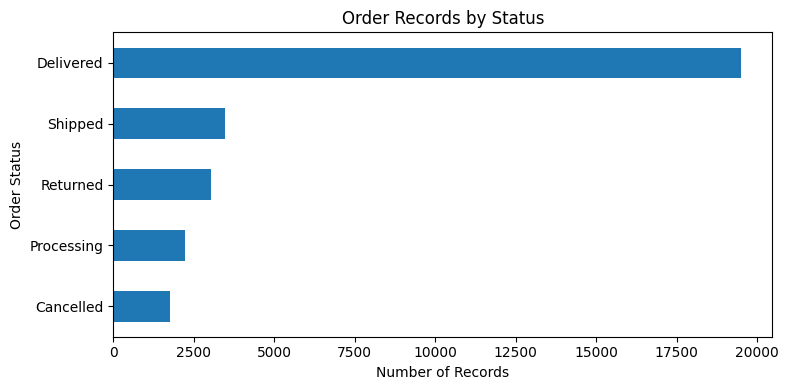

In [12]:
status_analysis["Record_Count"].sort_values().plot(
    kind="barh",
    figsize=(8, 4),
    title="Order Records by Status",
    xlabel="Number of Records",
    ylabel="Order Status"
)

plt.tight_layout()
plt.show()

###  Order Status Analysis

**Objective:** To understand the distribution of order records across order statuses.

**Business Interpretation:** The status distribution can help identify whether a substantial share of records is associated with completed, pending, cancelled, or other order states. Revenue and profit attributed to each status should be interpreted according to the dataset's definitions; recorded revenue does not automatically mean that payment was collected.

**Business Recommendations:**

1. Monitor the proportion of pending and cancelled orders.
2. Investigate recurring reasons for cancellations or delays, if supporting data is available.
3. Track completed orders separately when evaluating realized sales.
4. Validate how revenue and profit are recorded for each status before making financial decisions.

**Conclusion:** Monitoring order statuses can help improve order processing and reporting accuracy.


In [13]:
shipping_analysis = (
    df.groupby("Product_Category")
      .agg(
          Total_Revenue=("Order_Amount", "sum"),
          Total_Profit=("Profit_Amount", "sum"),
          Total_Shipping_Cost=("Shipping_Cost", "sum"),
          Average_Shipping_Cost=("Shipping_Cost", "mean"),
          Record_Count=("Order_ID", "size")
      )
)

shipping_analysis["Shipping_Cost_Percent"] = (
    shipping_analysis["Total_Shipping_Cost"]
    / shipping_analysis["Total_Revenue"] * 100
)

display(
    shipping_analysis.sort_values(
        "Total_Shipping_Cost", ascending=False
    ).round(2)
)

,Total_Revenue,Total_Profit,Total_Shipping_Cost,Average_Shipping_Cost,Record_Count,Shipping_Cost_Percent
Product_Category,,,,,,
Fashion,1323929.17,344642.74,63603.35,10.44,6092,4.80
Groceries,360727.15,76057.26,54975.24,10.22,5380,15.24
Electronics,6320059.31,1040688.00,48409.64,10.30,4699,0.77
Home & Kitchen,1768963.43,379418.20,43460.14,10.36,4194,2.46
Beauty,460243.32,134401.18,30800.98,10.37,2971,6.69
Sports,661447.69,139758.27,24890.70,10.21,2439,3.76
Books,195366.69,40799.67,22226.44,10.28,2163,11.38
Toys,279307.23,60150.95,21136.88,10.25,2062,7.57


In [14]:
shipping_profit_correlation = df[
    ["Shipping_Cost", "Profit_Amount"]
].corr().iloc[0, 1]

print(
    "Correlation between Shipping Cost and Profit:",
    round(shipping_profit_correlation, 3)
)

Correlation between Shipping Cost and Profit: 0.097


### Shipping Cost and Profitability Analysis

**Objective:** To investigate shipping costs across product categories and examine their relationship with profit.

**Business Interpretation:** Categories with high total shipping costs may require further investigation, but total costs should be evaluated alongside sales volume and revenue. The correlation between shipping cost and profit describes a relationship in the dataset and does not establish causation.

**Business Recommendations:**

1. Compare shipping costs across product categories and order sizes.
2. Review shipping arrangements for categories with relatively high shipping costs.
3. Evaluate whether shipping charges and delivery options support profitability and customer satisfaction.
4. Consider product weight, delivery distance, and order value if these details become available.

**Conclusion:** Monitoring shipping costs can help identify opportunities to improve operational efficiency without compromising the customer experience.


In [15]:
# Overall performance
total_revenue = df["Order_Amount"].sum()
total_profit = df["Profit_Amount"].sum()

overall_margin = (
    total_profit / total_revenue * 100
    if total_revenue != 0 else 0
)

# Best category by total profit
category_summary = df.groupby("Product_Category").agg(
    Revenue=("Order_Amount", "sum"),
    Profit=("Profit_Amount", "sum")
)

category_summary["Margin_Percent"] = (
    category_summary["Profit"]
    / category_summary["Revenue"] * 100
)

best_profit_category = category_summary["Profit"].idxmax()
best_margin_category = category_summary["Margin_Percent"].idxmax()

# Discount group results from Section 4.3
discount_summary = df.copy()

discount_summary["Discount_Group"] = pd.cut(
    discount_summary["Discount_Percent"],
    bins=[-0.01, 10, 20, 30, 40],
    labels=["0–10%", "10–20%", "20–30%", "30–40%"]
)

discount_summary = discount_summary.groupby(
    "Discount_Group", observed=False
).agg(
    Total_Profit=("Profit_Amount", "sum"),
    Total_Revenue=("Order_Amount", "sum")
)

discount_summary["Profit_Margin_Percent"] = (
    discount_summary["Total_Profit"]
    / discount_summary["Total_Revenue"] * 100
)

best_discount_group = discount_summary[
    "Profit_Margin_Percent"
].idxmax()

print("BUSINESS PERFORMANCE SUMMARY")
print("-" * 35)
print(f"Total Revenue: {total_revenue:,.2f}")
print(f"Total Profit: {total_profit:,.2f}")
print(f"Overall Profit Margin: {overall_margin:.2f}%")
print(f"Highest-Profit Category: {best_profit_category}")
print(f"Highest-Margin Category: {best_margin_category}")
print(f"Best Discount Group by Margin: {best_discount_group}")

BUSINESS PERFORMANCE SUMMARY
-----------------------------------
Total Revenue: 11,370,043.99
Total Profit: 2,215,916.27
Overall Profit Margin: 19.49%
Highest-Profit Category: Electronics
Highest-Margin Category: Beauty
Best Discount Group by Margin: 0–10%


### Final Business Recommendations

**1. Improve Discount Strategy**

The 0–10% discount group achieved the highest total profit and profit margin among the discount groups analysed. The business should evaluate whether lower discounts can maintain customer demand while protecting profitability.

**2. Improve Electronics Profitability**

Electronics generated the highest total revenue (6,320,059.31) and total profit (1,040,688.00), but its profit margin was 16.47%, below the overall margin of 19.49%. The business should review product costs, discount practices, and other operating expenses in this category.

**3. Learn from High-Margin Categories**

Beauty achieved the highest category profit margin at 29.20%, followed by Fashion at 26.03%. The business should investigate the factors contributing to these margins and determine whether similar practices can be applied to other categories.

**4. Monitor Low Average Profit**

Groceries had the highest record count (5,380) but the lowest average profit per record (14.14) among the product categories. The business should investigate pricing, procurement costs, and the economics of individual transactions.

**5. Track Profitability Regularly**

Revenue alone does not provide a complete picture of business performance. Management should monitor total profit, profit margin, average profit, discount levels, and shipping costs together.

**6. Use Customer and Monthly Trends**

Customer segment and monthly analyses can help identify valuable customer groups and periods requiring attention. Marketing and inventory decisions should be based on the actual results of these analyses.

**7. Investigate Operational Costs**

Shipping costs and order statuses should be monitored to identify potential operational improvements. Any changes should be evaluated against customer satisfaction and actual financial outcomes.

### Final Conclusion

This project analysed e-commerce sales and profitability using Python, Pandas, NumPy, Matplotlib, and Seaborn. The analysis examined overall business performance, product category profitability, discount effectiveness, customer segments, monthly trends, order statuses, and shipping costs.

The dataset recorded total revenue of 11,370,043.99, total profit of 2,215,916.27, and an overall profit margin of 19.49%. Electronics was the largest contributor to total revenue and profit, while Beauty recorded the highest category profit margin. Lower discount groups also showed stronger profit margins than higher discount groups.

These findings suggest opportunities to review discount policies, improve category-level profitability, monitor operating costs, and make decisions using both revenue and profit measures.

The analysis provides evidence-based recommendations for improving profitability. Further investigation would be needed to establish the causes of these patterns and estimate the financial impact of any proposed business changes.


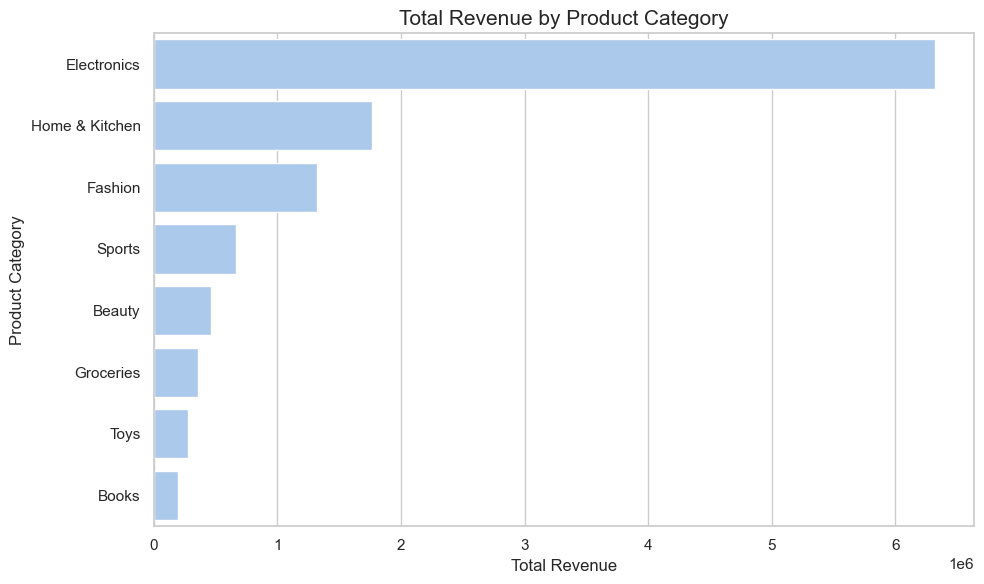

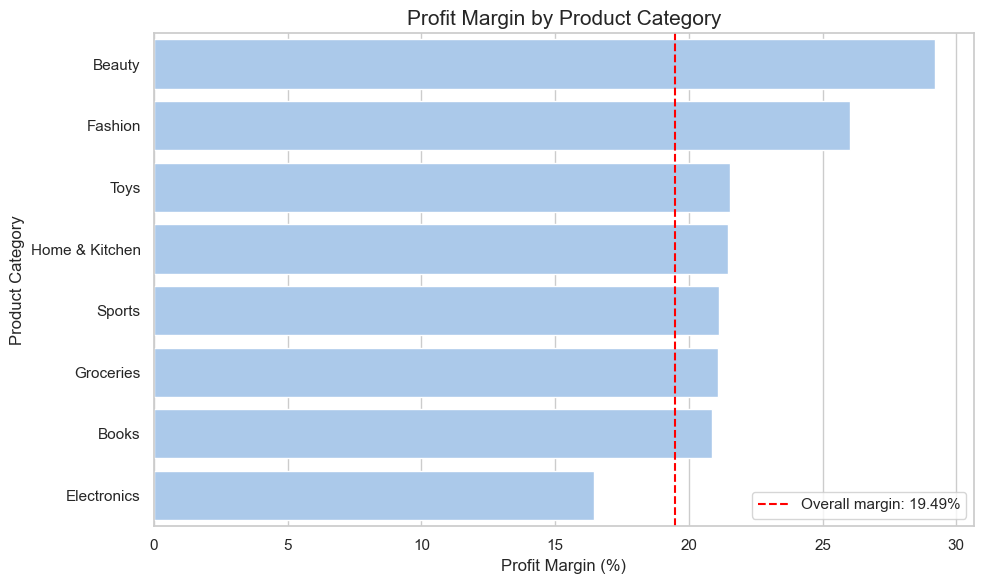

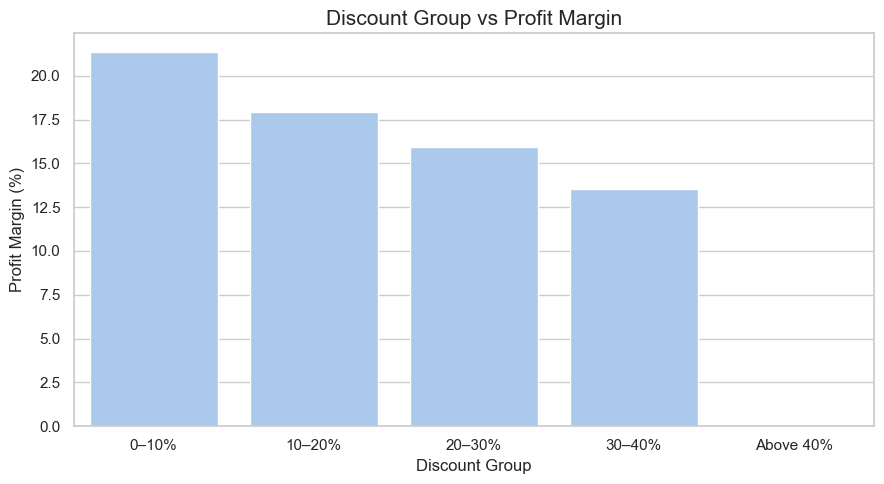

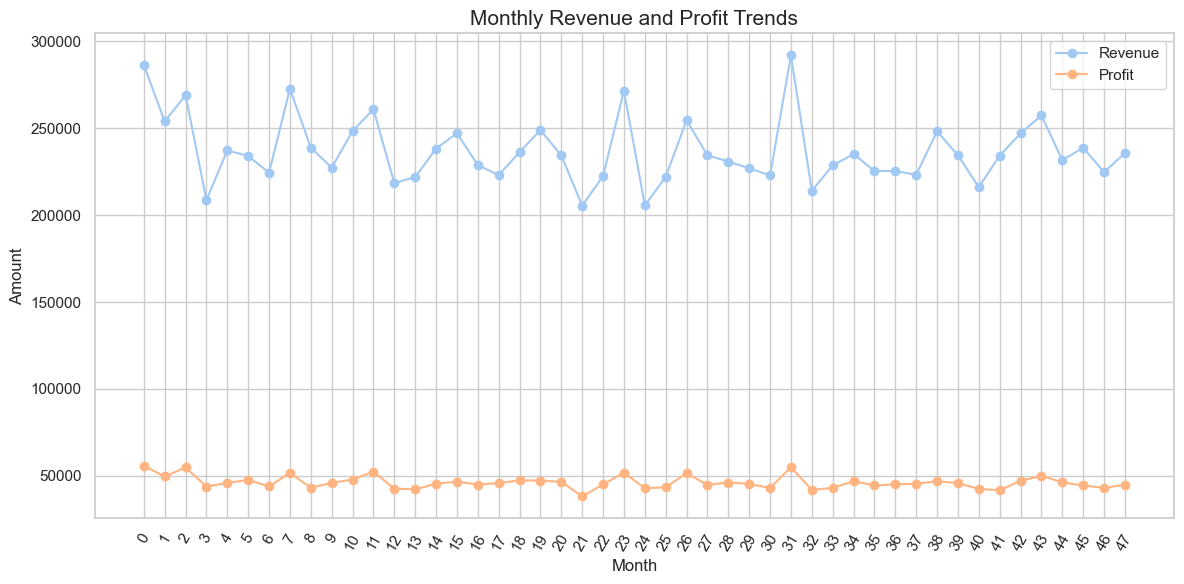

Charts saved successfully!
Location: C:\Users\ASUS\OneDrive\Desktop\Ecommerce-Sales-Profitability-Analysis\visualizations

Files created:
01_revenue_by_category.png
02_profit_margin_by_category.png
03_discount_vs_profit_margin.png
04_monthly_revenue_profit.png


In [ ]:

import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Create the folder to save charts
output_folder = r"C:\Users\ASUS\OneDrive\Desktop\Ecommerce-Sales-Profitability-Analysis\visualizations"
os.makedirs(output_folder, exist_ok=True)

# Load cleaned data
df = pd.read_csv(
    r"C:\Users\ASUS\OneDrive\Desktop\Ecommerce-Sales-Profitability-Analysis\data\cleaned\ecommerce_orders_cleaned.csv"
)

# Set a clean pastel theme
sns.set_theme(style="whitegrid", palette="pastel")


# ==================================================
# CHART 1: REVENUE BY PRODUCT CATEGORY
# ==================================================

category_revenue = (
    df.groupby("Product_Category")["Order_Amount"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))
sns.barplot(
    x=category_revenue.values,
    y=category_revenue.index
)
plt.title("Total Revenue by Product Category", fontsize=15)
plt.xlabel("Total Revenue")
plt.ylabel("Product Category")
plt.tight_layout()

plt.savefig(
    os.path.join(output_folder, "01_revenue_by_category.png"),
    dpi=300,
    bbox_inches="tight"
)
plt.show()
plt.close()


# ==================================================
# CHART 2: PROFIT MARGIN BY PRODUCT CATEGORY
# ==================================================

category_profit = df.groupby("Product_Category").agg(
    Total_Revenue=("Order_Amount", "sum"),
    Total_Profit=("Profit_Amount", "sum")
)

category_profit["Profit_Margin"] = (
    category_profit["Total_Profit"]
    / category_profit["Total_Revenue"] * 100
)

category_profit = category_profit.sort_values(
    "Profit_Margin", ascending=False
)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=category_profit.reset_index(),
    x="Profit_Margin",
    y="Product_Category"
)
plt.axvline(
    19.49, color="red", linestyle="--",
    label="Overall margin: 19.49%"
)
plt.title("Profit Margin by Product Category", fontsize=15)
plt.xlabel("Profit Margin (%)")
plt.ylabel("Product Category")
plt.legend()
plt.tight_layout()

plt.savefig(
    os.path.join(output_folder, "02_profit_margin_by_category.png"),
    dpi=300,
    bbox_inches="tight"
)
plt.show()
plt.close()


# ==================================================
# CHART 3: DISCOUNT GROUP VS PROFIT MARGIN
# ==================================================

df["Discount_Group"] = pd.cut(
    df["Discount_Percent"],
    bins=[-0.01, 10, 20, 30, 40, float("inf")],
    labels=["0–10%", "10–20%", "20–30%", "30–40%", "Above 40%"],
    include_lowest=True
)

discount_analysis = df.groupby(
    "Discount_Group", observed=False
).agg(
    Total_Revenue=("Order_Amount", "sum"),
    Total_Profit=("Profit_Amount", "sum")
)

discount_analysis["Profit_Margin"] = (
    discount_analysis["Total_Profit"]
    / discount_analysis["Total_Revenue"].replace(0, float("nan"))
    * 100
)

discount_analysis = discount_analysis.dropna(
    subset=["Profit_Margin"]
)

plt.figure(figsize=(9, 5))
sns.barplot(
    data=discount_analysis.reset_index(),
    x="Discount_Group",
    y="Profit_Margin"
)
plt.title("Discount Group vs Profit Margin", fontsize=15)
plt.xlabel("Discount Group")
plt.ylabel("Profit Margin (%)")
plt.tight_layout()

plt.savefig(
    os.path.join(output_folder, "03_discount_vs_profit_margin.png"),
    dpi=300,
    bbox_inches="tight"
)
plt.show()
plt.close()


# ==================================================
# CHART 4: MONTHLY REVENUE AND PROFIT TRENDS
# ==================================================

df["Order_Date"] = pd.to_datetime(
    df["Order_Date"], errors="coerce"
)

monthly = (
    df.dropna(subset=["Order_Date"])
    .groupby(df["Order_Date"].dt.to_period("M"))
    .agg(
        Revenue=("Order_Amount", "sum"),
        Profit=("Profit_Amount", "sum")
    )
    .reset_index(drop=True)
)

monthly["Month"] = monthly.index.astype(str)

plt.figure(figsize=(12, 6))
plt.plot(
    monthly["Month"], monthly["Revenue"],
    marker="o", label="Revenue"
)
plt.plot(
    monthly["Month"], monthly["Profit"],
    marker="o", label="Profit"
)
plt.title("Monthly Revenue and Profit Trends", fontsize=15)
plt.xlabel("Month")
plt.ylabel("Amount")
plt.xticks(rotation=60)
plt.legend()
plt.tight_layout()

plt.savefig(
    os.path.join(output_folder, "04_monthly_revenue_profit.png"),
    dpi=300,
    bbox_inches="tight"
)
plt.show()
plt.close()



print("Charts saved successfully!")
print("Location:", output_folder)
print("\nFiles created:")
for file in sorted(os.listdir(output_folder)):
    if file.endswith(".png"):
        print(file)